In [1]:
from DeepCPR.DeepCPR import data_resolution
import numpy as np
import os
import pandas as pd

In [ ]:
dataset_path = "example/data/ipynb_example_data"
save_path = 'example'
DeepCS_path = 'example/DeepCS.h5'
DeepCPR_path = 'example/DeepCPR.h5'

data_resolution(dataset_path, DeepCS_path, DeepCPR_path, save_path, True)

file loading: zhi50-5vs1.CDF


resolving processing: 100%|████████████████████████████████████████████████████████████| 25/25 [03:22<00:00,  8.11s/it]


<Figure size 640x480 with 0 Axes>

p_value =  0.0004997501249375312


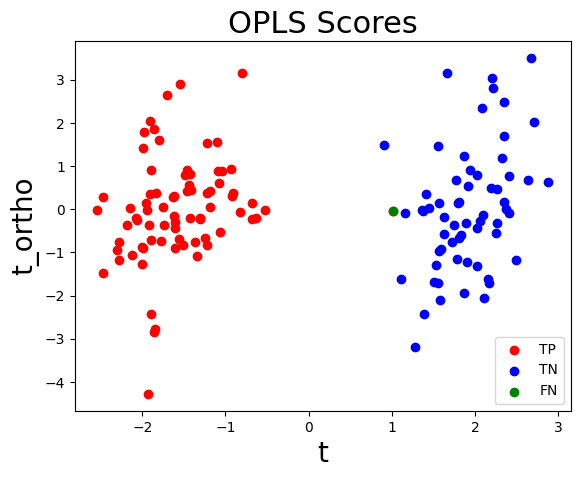

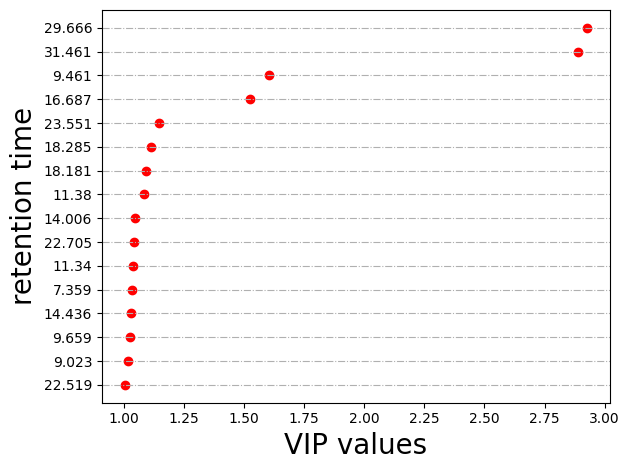

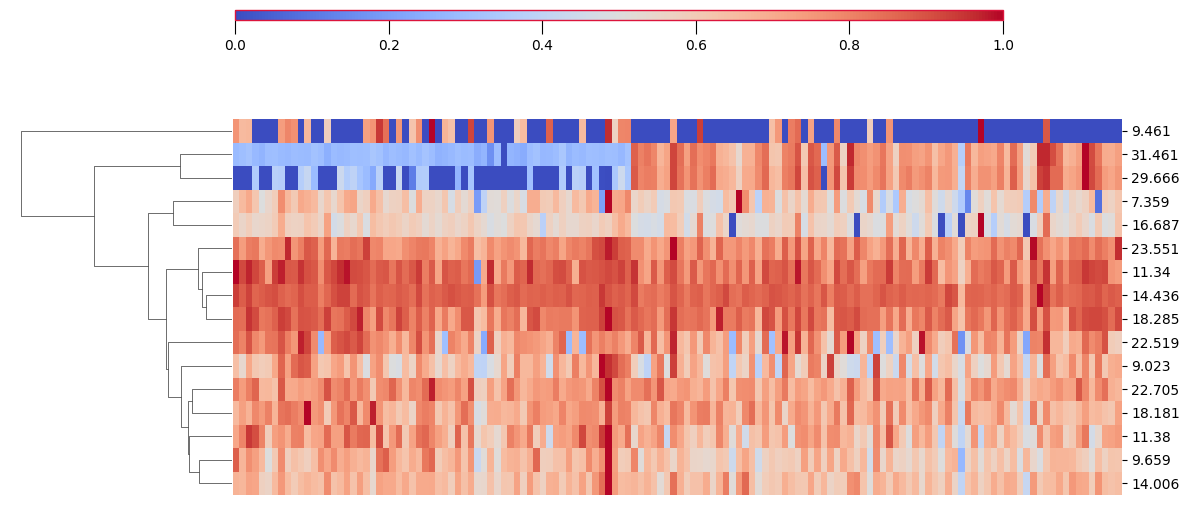

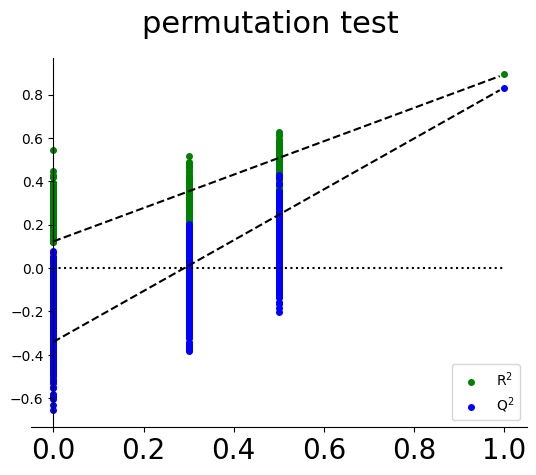

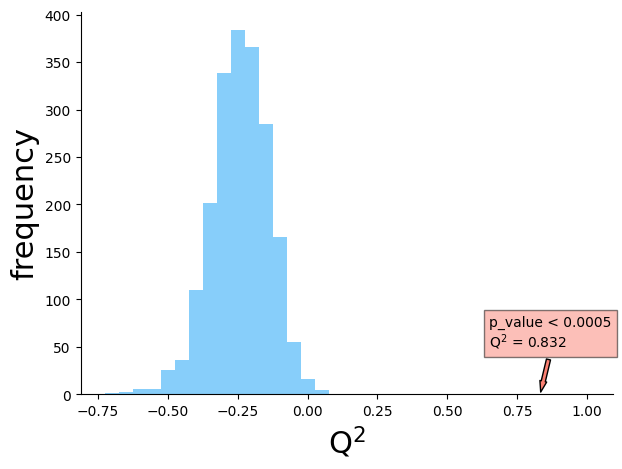

In [ ]:
from DeepCPR.OPLSDA import OPLS, scatter_cluster, vip_objection, heatmap, permutation_test
opls_savepath = 'example'
peak_table_data = pd.read_csv('example/Table S11.csv', index_col=0)
COMs = peak_table_data.columns.values

data = peak_table_data.values
data = data.astype(float)
origin_data = np.copy(data)

catnumber = 61  # The first 61 samples belong to the same group for this dataset
target = np.zeros((data.shape[0], 1))
target[0:catnumber, 0] = 1
target[catnumber:, 0] = -1

modelDF, summaryDF, VIP_df, xcvTraMN, toVn, tVn = OPLS(data, target, 10)

scatter_cluster(peak_table_data, target, toVn, tVn, opls_savepath)
VIP, COMS = vip_objection(data, VIP_df, COMs, opls_savepath)
heatmap(origin_data, VIP, VIP_df, COMS, opls_savepath)
permutation_test(opls_savepath, target, data, summaryDF)